In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(39).jpg
/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(22).jpg
/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(62).jpg
/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(52).jpg
/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(33).jpg
/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(68).jpg
/kaggle/input/datasets/abid074/guavadiseasedat

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, ConcatDataset, random_split
import os
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# 1. Define only the fruit folders
fruit_classes = ['Phytopthora', 'Scab', 'Styler and Root']

# 2. InceptionV3 REQUIRES 299x299 input size
transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def load_and_relabel(root_path):
    full_ds = datasets.ImageFolder(root_path, transform=transform)
    class_to_idx = {cls_name: i for i, cls_name in enumerate(fruit_classes)}
    filtered_samples = []
    for path, old_label in full_ds.samples:
        cls_name = full_ds.classes[old_label]
        if cls_name in fruit_classes:
            filtered_samples.append((path, class_to_idx[cls_name]))
    full_ds.samples = filtered_samples
    full_ds.imgs = filtered_samples
    full_ds.classes = fruit_classes
    full_ds.class_to_idx = class_to_idx
    return full_ds

base_path = '/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1'
orig_path = os.path.join(base_path, 'Guava Dataset (Original Image)/Guava Dataset (Original Image)')
aug_path = os.path.join(base_path, 'Guava Disease( Augmented Image)/Guava Disease( Augmented Image)')

full_dataset = ConcatDataset([load_and_relabel(orig_path), load_and_relabel(aug_path)])

train_size = int(0.70 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Total Fruit Images: {len(full_dataset)}")

Total Fruit Images: 3183


In [4]:
model = models.inception_v3(weights='DEFAULT')

# 1. Handle Main Classifier
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 3)

# 2. Handle Auxiliary Classifier (Essential for InceptionV3 Training)
num_ftrs_aux = model.AuxLogits.fc.in_features
model.AuxLogits.fc = nn.Linear(num_ftrs_aux, 3)

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("InceptionV3 model configured for 3 classes.")

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 246MB/s] 


InceptionV3 model configured for 3 classes.


In [5]:
num_epochs = 10

print("Starting InceptionV3 Training...")

for epoch in range(num_epochs):
    start_time = time.time()
    
    # --- Training Phase ---
    model.train()
    train_loss, train_corrects = 0.0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        # InceptionV3 returns (main_output, aux_output) during training
        outputs, aux_outputs = model(inputs)
        
        loss_main = criterion(outputs, labels)
        loss_aux = criterion(aux_outputs, labels)
        loss = loss_main + 0.4 * loss_aux  # Weighted sum of losses
        
        loss.backward()
        optimizer.step()
        
        _, preds = torch.max(outputs, 1)
        train_loss += loss.item() * inputs.size(0)
        train_corrects += torch.sum(preds == labels.data)

    epoch_train_loss = train_loss / len(train_dataset)
    epoch_train_acc = train_corrects.double() / len(train_dataset)

    # --- Validation Phase ---
    model.eval()
    val_loss, val_corrects = 0.0, 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            # In eval mode, InceptionV3 only returns the main output
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)
            
    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = val_corrects.double() / len(val_dataset)

    # Display Metrics
    print(f'Epoch {epoch+1}/{num_epochs} | {time.time()-start_time:.1f}s')
    print(f'  Train -> Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f}')
    print(f'  Val   -> Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}')
    print("-" * 40)

print("\nTraining Finished!")

Starting InceptionV3 Training...
Epoch 1/10 | 65.2s
  Train -> Loss: 0.5173 Acc: 0.8546
  Val   -> Loss: 0.1850 Acc: 0.9203
----------------------------------------
Epoch 2/10 | 57.5s
  Train -> Loss: 0.2173 Acc: 0.9448
  Val   -> Loss: 0.2085 Acc: 0.9140
----------------------------------------
Epoch 3/10 | 55.0s
  Train -> Loss: 0.1779 Acc: 0.9547
  Val   -> Loss: 0.2004 Acc: 0.9329
----------------------------------------
Epoch 4/10 | 55.5s
  Train -> Loss: 0.1661 Acc: 0.9569
  Val   -> Loss: 0.1902 Acc: 0.9413
----------------------------------------
Epoch 5/10 | 56.0s
  Train -> Loss: 0.1357 Acc: 0.9654
  Val   -> Loss: 0.1618 Acc: 0.9350
----------------------------------------
Epoch 6/10 | 55.7s
  Train -> Loss: 0.0902 Acc: 0.9771
  Val   -> Loss: 0.0945 Acc: 0.9748
----------------------------------------
Epoch 7/10 | 55.6s
  Train -> Loss: 0.0875 Acc: 0.9776
  Val   -> Loss: 0.0566 Acc: 0.9811
----------------------------------------
Epoch 8/10 | 55.7s
  Train -> Loss: 0.0344 

In [6]:
model.eval()
test_corrects = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        test_corrects += torch.sum(preds == labels.data)

final_acc = (test_corrects.double() / len(test_dataset)) * 100
print(f"Final Test Accuracy: {final_acc:.2f}%")

# Save Inception Model
torch.save(model.state_dict(), '/kaggle/working/inception_v3_guava.pth')

Final Test Accuracy: 97.07%


Generating predictions for Confusion Matrix...


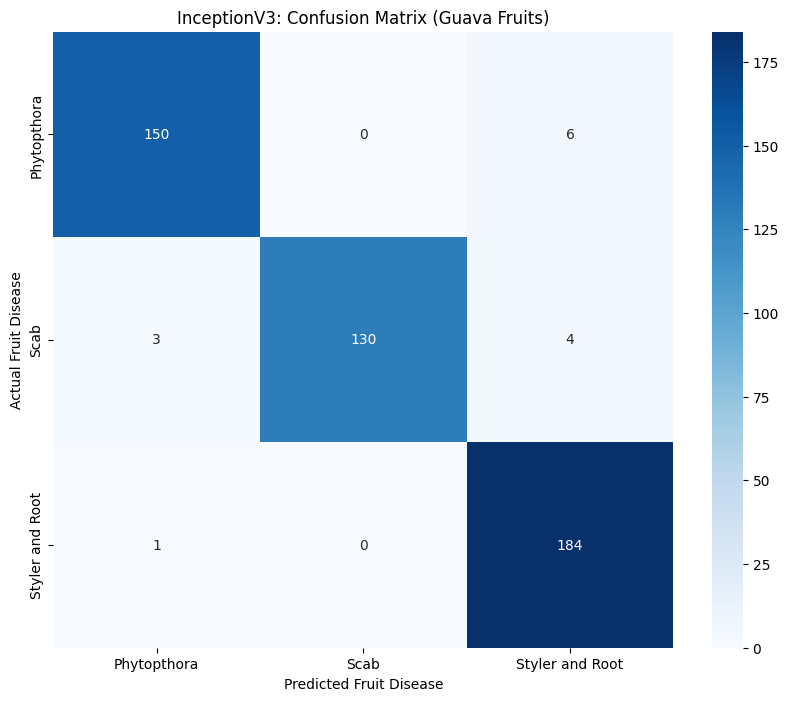


Detailed Classification Report (InceptionV3):
                 precision    recall  f1-score   support

    Phytopthora       0.97      0.96      0.97       156
           Scab       1.00      0.95      0.97       137
Styler and Root       0.95      0.99      0.97       185

       accuracy                           0.97       478
      macro avg       0.97      0.97      0.97       478
   weighted avg       0.97      0.97      0.97       478



In [7]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# 1. Collect all predictions and true labels from the test set
all_preds = []
all_labels = []

model.eval()
print("Generating predictions for Confusion Matrix...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        # InceptionV3 returns only main output in eval mode
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 2. Define class names (Must match your fruit_classes order)
class_names = ['Phytopthora', 'Scab', 'Styler and Root']

# 3. Generate the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# 4. Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)

plt.xlabel('Predicted Fruit Disease')
plt.ylabel('Actual Fruit Disease')
plt.title('InceptionV3: Confusion Matrix (Guava Fruits)')
plt.show()

# 5. Print Detailed Metrics
print("\nDetailed Classification Report (InceptionV3):")
print(classification_report(all_labels, all_preds, target_names=class_names))

Calculating probabilities for ROC Curve...


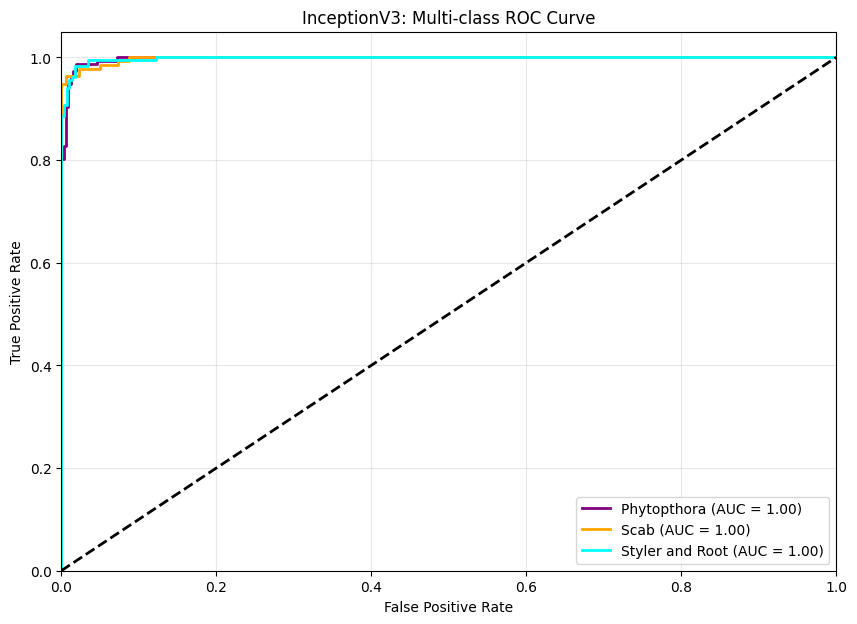

In [8]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# 1. Get predicted probabilities
model.eval()
all_probs = []
all_labels = []

print("Calculating probabilities for ROC Curve...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        
        # Softmax converts raw output to probabilities for each class
        probs = torch.nn.functional.softmax(outputs, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# 2. Prepare labels for 3-class ROC
n_classes = 3
bin_labels = label_binarize(all_labels, classes=[0, 1, 2])
class_names = ['Phytopthora', 'Scab', 'Styler and Root']

# 3. Compute ROC and AUC
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(bin_labels[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Plot the results
plt.figure(figsize=(10, 7))
colors = ['purple', 'orange', 'cyan']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('InceptionV3: Multi-class ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()